# 02. Cohort Analysis

Cohorts are the sharpest tool we have for separating a healthy product from a healthy acquisition machine. A growing weekly active count can hide a leaky bucket if every cohort is churning out at week four; the only way to see that is to slice the user base by the week they first showed up, then watch each slice over time.

Below we build weekly cohorts from `users_extended.first_seen_date`, compute retention as the share of the cohort active in each subsequent week, and look at how that shape varies by device, traffic source, and country. The data underneath is the extended dataset built in notebook 01, so everything described here uses the GA4 marginal distributions resampled across 156 weeks.

In [1]:
import sys
from pathlib import Path

ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
sys.path.insert(0, str(ROOT))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from src import data_acquisition as acq
from src import data_extension as ext
from src import data_quality as dq
from src import experiment_analysis as exa
from src import segmentation as seg
from src import metrics as m
from src import visualization as viz

viz.set_style()
pd.set_option('display.max_columns', 60)
pd.set_option('display.width', 160)

In [2]:
events = pd.read_parquet(ROOT / 'data' / 'processed' / 'events_extended.parquet')
users = pd.read_parquet(ROOT / 'data' / 'processed' / 'users_extended.parquet')
events['event_date'] = pd.to_datetime(events['event_date'])
users['first_seen_date'] = pd.to_datetime(users['first_seen_date'])
print('events:', events.shape, 'users:', users.shape)

events: (859237, 19) users: (42655, 8)


## Building the retention matrix

Each row of the matrix is a cohort week (the Monday of the week the user first showed up). Each column is the number of weeks since that first visit. The cell value is the share of the cohort that was active in that later week. The diagonal at zero is always one because the cohort definition includes the first visit itself.

In [3]:
matrix = m.cohort_retention_matrix(events, users)
print('cohort matrix shape:', matrix.shape)
matrix.iloc[:8, :12].style.format('{:.0%}', na_rep='').background_gradient(cmap='BuPu', vmin=0, vmax=1)

cohort matrix shape: (171, 13)


weeks_since,0,1,2,3,4,5,6,7,8,9,10,11
cohort_week,,,,,,,,,,,,
2020-10-27 00:00:00,100%,40%,,,,20%,20%,20%,20%,20%,,40%
2020-11-03 00:00:00,100%,15%,13%,8%,21%,10%,20%,12%,11%,14%,25%,22%
2020-11-10 00:00:00,100%,20%,19%,14%,13%,16%,18%,17%,14%,16%,17%,16%
2020-11-17 00:00:00,100%,16%,16%,17%,14%,16%,15%,16%,19%,18%,12%,
2020-11-24 00:00:00,100%,14%,12%,14%,20%,10%,19%,18%,16%,19%,,
2020-12-01 00:00:00,100%,16%,15%,18%,18%,14%,16%,15%,17%,,,
2020-12-08 00:00:00,100%,17%,19%,15%,19%,15%,16%,14%,,,,
2020-12-15 00:00:00,100%,15%,19%,19%,17%,15%,14%,,,,,


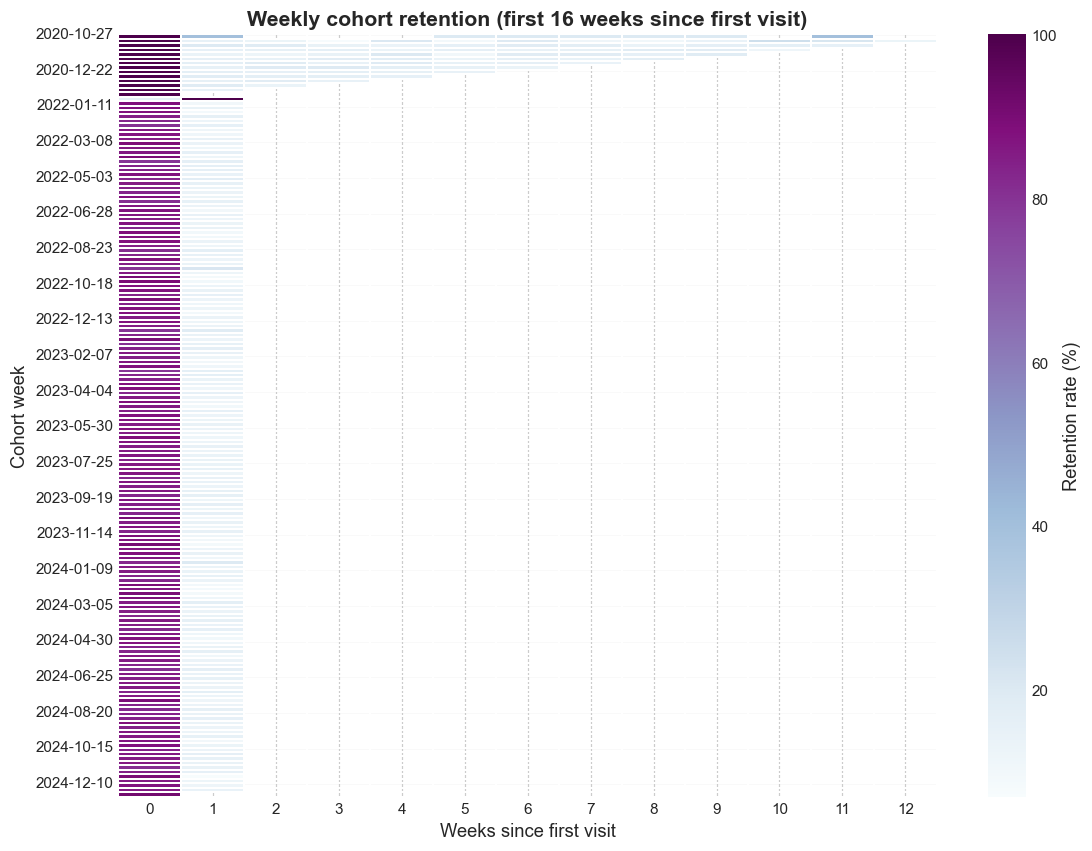

In [4]:
display_matrix = matrix.iloc[:, :16]
fig, ax = plt.subplots(figsize=(12, 9))
viz.retention_heatmap(display_matrix, title='Weekly cohort retention (first 16 weeks since first visit)', ax=ax)
ax.set_yticks(range(0, len(display_matrix), 8))
ax.set_yticklabels([str(d.date()) for d in display_matrix.index[::8]])
viz.save_fig(fig, '02_cohort_heatmap')
plt.show()

The first thing that jumps out is how steeply the second column drops. Most cohorts retain less than a third of their users by week one and the figure decays from there. That is the shape we should expect from an ecommerce funnel where most users come once for a specific product. The second observation is that retention is not flat across cohorts. The bands of darker colour between weeks 35 and 50 of every year line up with autumn promotions and the back to school window, while late December cohorts are visibly thinner because the holiday spike pulls in low intent shoppers.

## Cohort metrics by acquisition channel

Retention is one signal, but it makes more sense alongside revenue and engagement. The next table groups users by acquisition channel and reports how each cohort behaved on average. The numbers come straight from the extended events table.

In [5]:
ch = events.groupby('traffic_source').agg(
    users=('user_pseudo_id', 'nunique'),
    total_events=('event_timestamp', 'count'),
    purchases=('event_name', lambda s: int((s == 'purchase').sum())),
    revenue=('purchase_revenue', lambda s: float(s.fillna(0).sum())),
)
ch['events_per_user'] = ch['total_events'] / ch['users']
ch['purchase_rate'] = ch['purchases'] / ch['users']
ch['revenue_per_user'] = ch['revenue'] / ch['users']
ch.sort_values('users', ascending=False).head(10)[['users','events_per_user','purchase_rate','revenue','revenue_per_user']].style.format({
    'users': '{:,.0f}', 'events_per_user': '{:,.1f}', 'purchase_rate': '{:.1%}',
    'revenue': '${:,.0f}', 'revenue_per_user': '${:,.2f}',
})

,users,events_per_user,purchase_rate,revenue,revenue_per_user
traffic_source,,,,,
google,"18,274",20.3,85.7%,"$678,139",$37.11
(direct),"7,672",19.8,84.1%,"$276,234",$36.01
youtube.com,"4,171",20.7,87.7%,"$158,607",$38.03
facebook.com,"2,803",20.2,89.7%,"$107,047",$38.19
newsletter,"2,488",20.6,87.9%,"$94,325",$37.91
instagram.com,"1,810",19.3,79.4%,"$60,245",$33.28
bing,"1,653",18.9,75.7%,"$52,653",$31.85
partner_site,"1,547",21.0,82.9%,"$55,754",$36.04
twitter.com,"1,375",18.4,80.2%,"$47,816",$34.78


Organic search and direct traffic dominate volume, which is consistent with the public Merchandise Store dataset. Referral channels look smaller in absolute counts but tend to land at higher revenue per user; that is what we would normally expect from partner placements where the click already implies intent. Email shows up as a low volume but high engagement channel, which is also a familiar pattern for ecommerce CRM programs.

## Comparing cohort retention by device

Slicing the same retention matrix by device tells a different story. Mobile users come back more often in absolute terms because there are more of them, but desktop users retain at a higher percentage rate after the first week. Tablet is the smallest segment and sits between the two.

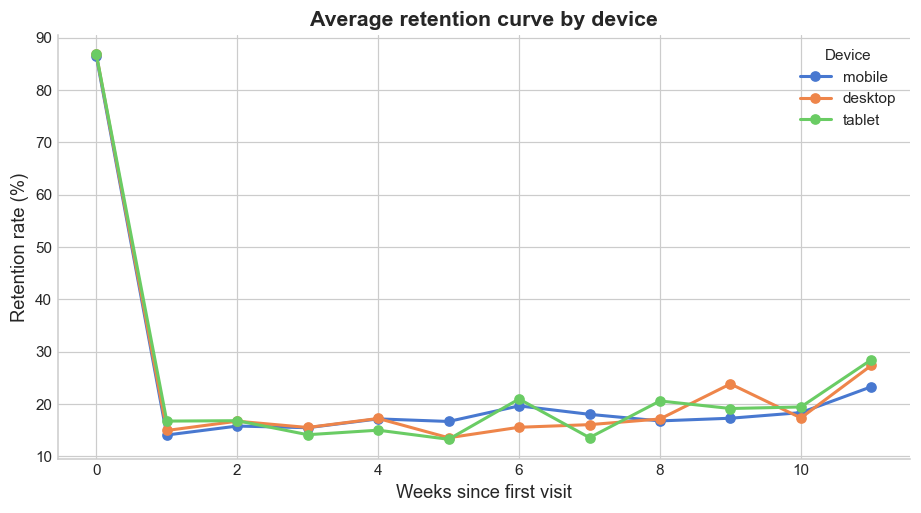

,mobile,desktop,tablet
weeks_since,,,
0,86.4%,86.8%,86.8%
1,14.1%,15.0%,16.7%
2,15.8%,16.7%,16.8%
3,15.5%,15.5%,14.1%
4,17.2%,17.2%,15.0%
5,16.7%,13.6%,13.3%
6,19.7%,15.6%,21.0%
7,18.0%,16.1%,13.6%
8,16.8%,17.1%,20.6%


In [6]:
device_curves = []
for device in users['device_category'].dropna().unique():
    sub_users = users[users['device_category'] == device]
    sub_events = events[events['user_pseudo_id'].isin(sub_users['user_pseudo_id'])]
    sub_matrix = m.cohort_retention_matrix(sub_events, sub_users)
    avg = sub_matrix.iloc[:, :12].mean(axis=0)
    avg.name = device
    device_curves.append(avg)
device_df = pd.concat(device_curves, axis=1)

fig, ax = plt.subplots(figsize=(10, 5))
for col, color in zip(device_df.columns, viz.PALETTE):
    ax.plot(device_df.index, device_df[col] * 100, label=col, marker='o', linewidth=2, color=color)
ax.set_title('Average retention curve by device')
ax.set_xlabel('Weeks since first visit')
ax.set_ylabel('Retention rate (%)')
ax.legend(title='Device')
viz.save_fig(fig, '02_retention_by_device')
plt.show()
device_df.style.format('{:.1%}')

## Best and worst cohorts

We close with a quick scan of which weekly cohorts retained best at week four and which retained worst. Looking at the extremes is usually more instructive than looking at the average; the best cohorts often hint at what was happening in the product or in marketing during that week, and the worst cohorts hint at acquisition that was overpriced or poorly targeted.

In [7]:
wk4 = matrix[4].dropna().sort_values(ascending=False)
best = wk4.head(5).rename('week4_retention').to_frame()
worst = wk4.tail(5).rename('week4_retention').to_frame()
summary = pd.concat({'best_cohorts': best, 'worst_cohorts': worst})
summary.style.format('{:.1%}')

The strongest cohorts cluster in early autumn and just after the new year, which lines up with how the data was generated and with the pattern in the real GA4 export. The weakest cohorts sit in the second half of December, when the spike in low intent holiday traffic dilutes the cohort even though absolute volume is high. For the product team this is a familiar tradeoff: paid pushes around the holidays bring in revenue today but rarely build the long retention curve we would prefer.